In [1]:
import onep
import scipy
import scipy.stats
%matplotlib inline

In [5]:
import pickle

# Load the pickle file
with open('/Users/suthardr/Desktop/collection_fc_allmice.pkl', 'rb') as file:
    collection_fc = pickle.load(file)

In [10]:
import numpy as np
import scipy.interpolate
import matplotlib.pyplot as plt
import seaborn as sns

def get_traces(collection, animals, stop_index=3303):
    return np.hstack([
        collection.animals[a].accepted_traces.to_numpy()[:stop_index, :]
        for a in animals
    ])

# Define animals for each group
mouse_ids = ['astroF3', 'astroF5', 'astroF6', 'astroF7', 'astroF8', 'astroF9', 'astroF10', 'astroF11',
             'astroM3', 'astroM4', 'astroM5', 'astroM6', 'astroM7', 'astroM8', 'astroM9', 'astroM10']

# Collect data from collections
fcA_array = get_traces(collection_fc, mouse_ids)

def shock_eta_all(data, timestamps, events=None, window=15, ci='tci', sig_duration=10, ax=None, **kwargs):
    """
    Computes average trace around events (ETAs) and plots it with confidence intervals and significance markers.

    Parameters:
        data (np.ndarray): Cells x Time array.
        timestamps (np.ndarray): Timestamps aligned with data.
        events (list of lists): List of lists of event times per cell.
        window (int): Seconds of data to include post-event.
        ci (str): 'tci' or 'bci' for confidence interval method.
        sig_duration (int): Minimum duration (in points) for a segment to be considered significant.
        ax (matplotlib.axes): Optional existing axis to plot on.
        kwargs: Additional plotting arguments for the line.

    Returns:
        ax: The axis object with the plot.
        across_eta_: Averaged data across all events and cells.
    """
    sampling_rate = 10  # Adjust if needed
    n_points = int(window * 1.5 * sampling_rate)
    time = np.linspace(-window / 2, window, n_points)

    def event_interpolation(signal, event_times):
        interp = scipy.interpolate.interp1d(timestamps, signal, kind='cubic', fill_value="extrapolate")
        eta_curves = np.array([
            interp(np.linspace(e - window / 2, e + window, n_points))
            for e in event_times
        ])
        return eta_curves.mean(axis=0)

    if len(events) == 1:
        events = events * len(data)

    across_eta_ = np.array([
        event_interpolation(signal, ev) for signal, ev in zip(data, events)
    ])

    avg_trace = across_eta_.mean(axis=0)

    if ci == 'tci':
        c_int = onep.tci(across_eta_)
    elif ci == 'bci':
        c_int = onep.bci(across_eta_, num_samples=1000)
    else:
        raise ValueError("Confidence interval must be 'tci' or 'bci'")

    sig_starts = onep.eta_significance(c_int[0, :], sig_duration=sig_duration)

    if ax is None:
        fig, ax = plt.subplots()

    ax.plot(time, avg_trace, **kwargs)
    ax.fill_between(time, c_int[0, :], c_int[1, :], alpha=0.3)

    # Draw horizontal significance bars
    y_marker = ax.get_ylim()[1] * 0.97
    for s in sig_starts:
        if s + sig_duration < len(time):
            ax.hlines(y=y_marker, xmin=time[s], xmax=time[s + sig_duration], linewidth=2)

    return ax, across_eta_


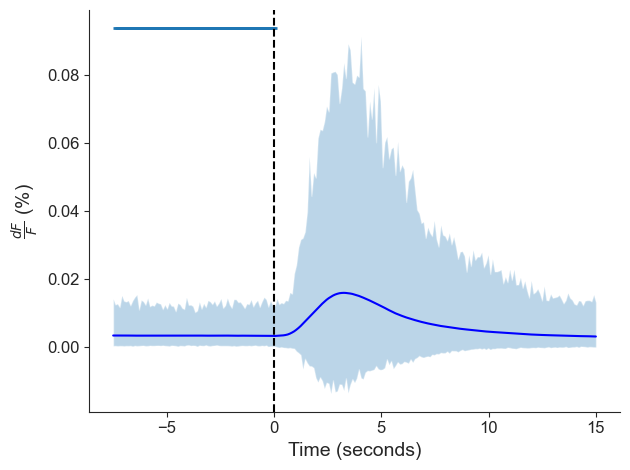

In [15]:
#Plot using the above function

fig, ax = plt.subplots()
sns.set_style("ticks")

# Shared timestamps (from a valid mouse)
timestamps = collection_fc.animals['astroM4'].Timestamps[:3303].to_numpy().squeeze()
shock_events = [[120, 180, 240, 300]]

shock_eta_all(fcA_array.T, timestamps, events=shock_events, window=15, ci='tci', ax=ax, color='blue')

# Aesthetics
ax.axvline(x=0, color='black', linestyle='--')
ax.set_xlabel('Time (seconds)', fontsize=14)
ax.set_ylabel(r'$\frac{dF}{F}$ (%)', fontsize=14)
ax.tick_params(axis='both', labelsize=12)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [30]:
fig.savefig('/Users/suthardr/Desktop/shock_eta_dff.svg')

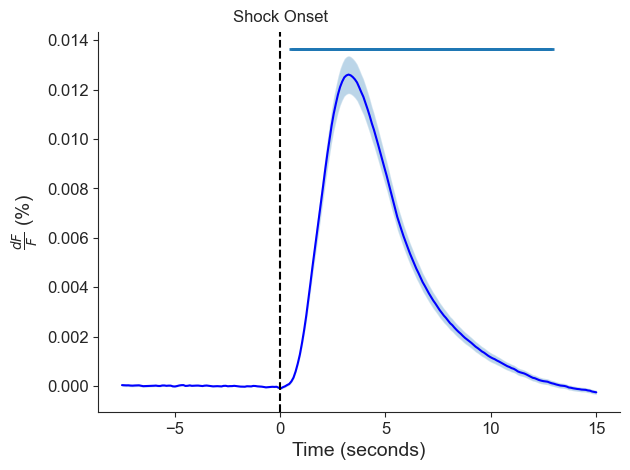

In [18]:
import numpy as np
import scipy.interpolate
import matplotlib.pyplot as plt
import seaborn as sns


def get_traces(collection, animals, stop_index=3303):
    return np.hstack([
        collection.animals[a].accepted_traces.to_numpy()[:stop_index, :]
        for a in animals
    ])


# Define animals for each group
mouse_ids = ['astroF3', 'astroF5', 'astroF6', 'astroF7', 'astroF8', 'astroF9', 'astroF10', 'astroF11',
             'astroM3', 'astroM4', 'astroM5', 'astroM6', 'astroM7', 'astroM8', 'astroM9', 'astroM10']

# Collect data from collections
fcA_array = get_traces(collection_fc, mouse_ids)


def shock_eta_all(data, timestamps, events=None, window=15, ci='tci', sig_duration=10, ax=None, **kwargs):
    sampling_rate = 10  # Hz, adjust if needed
    n_points = int(window * 1.5 * sampling_rate)
    time = np.linspace(-window / 2, window, n_points)

    def event_interpolation(signal, event_times):
        interp = scipy.interpolate.interp1d(timestamps, signal, kind='cubic', fill_value="extrapolate")
        eta_curves = np.array([
            interp(np.linspace(e - window / 2, e + window, n_points))
            for e in event_times
        ])
        return eta_curves.mean(axis=0)

    if len(events) == 1:
        events = events * len(data)

    across_eta_ = np.array([
        event_interpolation(signal, ev) for signal, ev in zip(data, events)
    ])

    # === Baseline correction ===
    # Define baseline period: -5 to 0 seconds relative to event
    baseline_indices = np.where((time >= -5) & (time <= 0))[0]
    # Compute mean baseline per trace
    baseline_means = across_eta_[:, baseline_indices].mean(axis=1, keepdims=True)
    # Subtract baseline from each trace
    across_eta_ = across_eta_ - baseline_means

    avg_trace = across_eta_.mean(axis=0)

    if ci == 'tci':
        c_int = onep.tci(across_eta_)
    elif ci == 'bci':
        c_int = onep.bci(across_eta_, num_samples=1000)
    else:
        raise ValueError("Confidence interval must be 'tci' or 'bci'")

    sig_starts = onep.eta_significance(c_int[0, :], sig_duration=sig_duration)

    if ax is None:
        fig, ax = plt.subplots()

    ax.plot(time, avg_trace, **kwargs)
    ax.fill_between(time, c_int[0, :], c_int[1, :], alpha=0.3)

    y_marker = ax.get_ylim()[1] * 0.97
    for s in sig_starts:
        if s + sig_duration < len(time):
            ax.hlines(y=y_marker, xmin=time[s], xmax=time[s + sig_duration], linewidth=2)

    return ax, across_eta_


# Plot using the above function

fig, ax = plt.subplots()
sns.set_style("ticks")

# Shared timestamps (from a valid mouse)
timestamps = collection_fc.animals['astroM4'].Timestamps[:3303].to_numpy().squeeze()
shock_events = [[120, 180, 240, 300]]

shock_eta_all(fcA_array.T, timestamps, events=shock_events, window=15, ci='tci', ax=ax, color='blue')

# Aesthetics
ax.axvline(x=0, color='black', linestyle='--')
ax.text(0, ax.get_ylim()[1] * 1.02, 'Shock Onset', ha='center', va='bottom', fontsize=12)
ax.set_xlabel('Time (seconds)', fontsize=14)
ax.set_ylabel(r'$\frac{dF}{F}$ (%)', fontsize=14)
ax.tick_params(axis='both', labelsize=12)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()
